In [1]:
import pandas as pd
from canexao import connect_to_mongo
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff




collection_users, collection_tasks = connect_to_mongo()
tabela_users = pd.DataFrame(list(collection_users.find()))
tabela = pd.DataFrame(list(collection_tasks.find()))


Conexão estabelecida com sucesso!


In [ ]:
tabela.head()

,_id,task_id,titulo,descricao,prioridade,user_id,mentorado,area_atuacao,mentor_responsavel,data_criacao,data_inicio,status_atual,data_conclusao,feedback_conclusao_mentorado,createdAt,updatedAt,__v
0,6a2b884993a2aac46c8ba14a,1.0,Otimizar Microsserviços - Sprint 8,Atividade focada em otimizar o recurso de micr...,media,6a2b8445cf36b576d237ae6b,Bruno Costa,DevBack-end,Juliana Costa,2026-05-05,2026-05-07,andamento,NaT,NaN,NaT,NaT,NaN
1,6a2b884993a2aac46c8ba14b,2.0,Testar Scripts de Deploy - Sprint 2,Atividade focada em testar o recurso de script...,alta,6a2b8468cf36b576d237ae6c,Felipe Andrade,QA,Juliana Costa,2026-03-25,2026-03-27,concluida,2026-04-02,Os testes cobriram os cenários críticos de aut...,NaT,NaT,NaN
2,6a2b884993a2aac46c8ba14c,3.0,Testar Cache em Redis - Sprint 2,Atividade focada em testar o recurso de cache ...,media,6a2b8468cf36b576d237ae6c,Felipe Andrade,QA,Juliana Costa,2026-03-26,2026-03-27,concluida,2026-04-06,Validação executada com sucesso. O fluxo corre...,NaT,NaT,NaN
3,6a2b884993a2aac46c8ba14d,4.0,Testar Componentes React - Sprint 8,Atividade focada em testar o recurso de compon...,media,6a2b8496cf36b576d237ae6d,Diego Martins,QA,Juliana Costa,2026-04-20,2026-04-21,concluida,2026-04-27,Conseguimos manter uma boa cobertura de testes...,NaT,NaT,NaN
4,6a2b884993a2aac46c8ba14e,5.0,Ajustar Exportação de Relatórios - Sprint 3,Atividade focada em ajustar o recurso de expor...,media,6a2b84b4cf36b576d237ae6e,Camila Lopes,Produto,Juliana Costa,2026-03-02,2026-03-05,concluida,2026-03-19,Os ajustes visuais foram concluídos no prazo. ...,NaT,NaT,NaN


In [ ]:
# Mostra o número de linhas, colunas e o tipo de dados de cada coluna
tabela.info()

# Mostra um resumo estatístico das colunas numéricas
tabela.describe()

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   _id                           77 non-null     object        
 1   task_id                       76 non-null     float64       
 2   titulo                        77 non-null     str           
 3   descricao                     77 non-null     str           
 4   prioridade                    77 non-null     str           
 5   user_id                       77 non-null     object        
 6   mentorado                     77 non-null     str           
 7   area_atuacao                  76 non-null     str           
 8   mentor_responsavel            77 non-null     str           
 9   data_criacao                  76 non-null     datetime64[us]
 10  data_inicio                   63 non-null     datetime64[us]
 11  status_atual                  77 non-null    

,task_id,data_criacao,data_inicio,data_conclusao,createdAt,updatedAt,__v
count,76.000000,76,63,44,1,1,1.0
mean,38.500000,2026-04-18 14:31:34.736842,2026-04-14 17:54:17.142857,2026-04-12 08:10:54.545454,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
min,1.000000,2026-03-01 00:00:00,2026-03-03 00:00:00,2026-03-09 00:00:00,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
25%,19.750000,2026-03-23 18:00:00,2026-03-23 12:00:00,2026-03-27 06:00:00,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
50%,38.500000,2026-04-28 00:00:00,2026-04-16 00:00:00,2026-04-05 12:00:00,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
75%,57.250000,2026-05-12 00:00:00,2026-05-08 12:00:00,2026-04-29 06:00:00,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
max,76.000000,2026-05-27 00:00:00,2026-06-11 00:00:00,2026-06-15 00:00:00,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
std,22.083176,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# 1. Converter as colunas de data de texto para o formato de data real (datetime)
tabela['data_criacao'] = pd.to_datetime(tabela['data_criacao'], errors='coerce')
tabela['data_inicio'] = pd.to_datetime(tabela['data_inicio'], errors='coerce')
tabela['data_conclusao'] = pd.to_datetime(tabela['data_conclusao'], errors='coerce')

# 2. Criar uma coluna útil: Tempo de Resolução (em dias) entre a criação e a conclusão
tabela['tempo_conclusao_dias'] = (tabela['data_conclusao'] - tabela['data_criacao']).dt.days

# Verificando se as transformações deram certo
tabela[['data_criacao', 'data_inicio', 'data_conclusao', 'tempo_conclusao_dias']].info()

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   data_criacao          76 non-null     datetime64[us]
 1   data_inicio           63 non-null     datetime64[us]
 2   data_conclusao        44 non-null     datetime64[us]
 3   tempo_conclusao_dias  43 non-null     float64       
dtypes: datetime64[us](3), float64(1)
memory usage: 2.5 KB


In [ ]:
tabela['tempo_conclusao_dias'].describe()

count    43.000000
mean     12.697674
std       5.307384
min       4.000000
25%       8.000000
50%      12.000000
75%      17.000000
max      23.000000
Name: tempo_conclusao_dias, dtype: float64

In [ ]:
# 1. Média de dias para concluir uma tarefa
media_dias = tabela['tempo_conclusao_dias'].mean()
mediana_dias = tabela['tempo_conclusao_dias'].median()
max_dias = tabela['tempo_conclusao_dias'].max()

print(f"⏱️ Tempo Médio de Conclusão: {media_dias:.1f} dias")
print(f"🎯 Mediana do Tempo (50% das tarefas): {mediana_dias:.1f} dias")
print(f"🚨 Tarefa mais demorada levou: {max_dias:.1f} dias")
print("-" * 50)

# 2. Qual área de atuação demora mais para concluir as tarefas?
print("🐢 Tempo médio de conclusão por ÁREA DE ATUAÇÃO:")
print(tabela.groupby('area_atuacao')['tempo_conclusao_dias'].mean().sort_values(ascending=False))
print("-" * 50)

# 3. Qual nível de prioridade está levando mais tempo?
print("⚠️ Tempo médio de conclusão por PRIORIDADE:")
print(tabela.groupby('prioridade')['tempo_conclusao_dias'].mean().sort_values(ascending=False))

⏱️ Tempo Médio de Conclusão: 12.7 dias
🎯 Mediana do Tempo (50% das tarefas): 12.0 dias
🚨 Tarefa mais demorada levou: 23.0 dias
--------------------------------------------------
🐢 Tempo médio de conclusão por ÁREA DE ATUAÇÃO:
area_atuacao
Data Engineer    15.200000
DevBack-end      13.857143
QA               12.500000
UX/UIDesigner    12.000000
DevMobile        10.800000
Produto          10.666667
DevFront-end     10.571429
Name: tempo_conclusao_dias, dtype: float64
--------------------------------------------------
⚠️ Tempo médio de conclusão por PRIORIDADE:
prioridade
media    13.157895
alta     12.533333
baixa    12.000000
Name: tempo_conclusao_dias, dtype: float64


In [ ]:
# 1. Distribuição Geral dos Status (Quantidade e Percentual)
print("📊 DISTRIBUIÇÃO GERAL DOS STATUS:")
status_qtd = tabela['status_atual'].value_counts()
status_pct = tabela['status_atual'].value_counts(normalize=True) * 100

for status in status_qtd.index:
    print(f"• {status}: {status_qtd[status]} tarefas ({status_pct[status]:.1f}%)")
print("-" * 50)

# 2. Quais áreas têm mais tarefas que ainda NÃO foram concluídas?
# Filtrando onde a data de conclusão está vazia (NaN)
print("⏳ TAREFAS PENDENTES (Não concluídas) POR ÁREA DE ATUAÇÃO:")
pendentes_por_area = tabela[tabela['data_conclusao'].isna()]['area_atuacao'].value_counts()
print(pendentes_por_area)
print("-" * 50)

# 3. Cruzamento: Quem está cuidando de quais status?
print("🤝 STATUS DAS TAREFAS POR MENTOR RESPONSÁVEL:")
print(pd.crosstab(tabela['mentor_responsavel'], tabela['status_atual']))

📊 DISTRIBUIÇÃO GERAL DOS STATUS:
• concluida: 44 tarefas (57.1%)
• andamento: 19 tarefas (24.7%)
• pendente: 14 tarefas (18.2%)
--------------------------------------------------
⏳ TAREFAS PENDENTES (Não concluídas) POR ÁREA DE ATUAÇÃO:
area_atuacao
QA               9
Data Engineer    6
DevMobile        5
Produto          4
DevBack-end      3
UX/UIDesigner    3
DevFront-end     3
Name: count, dtype: int64
--------------------------------------------------
🤝 STATUS DAS TAREFAS POR MENTOR RESPONSÁVEL:
status_atual        andamento  concluida  pendente
mentor_responsavel                                
Juliana Costa              19         44        14


C:\Users\lmm4\AppData\Local\Temp\ipykernel_27500\1599355491.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pendentes_por_area.values, y=pendentes_por_area.index, palette="danger_r" if "danger_r" in dir(sns.color_palette) else "Reds_r")


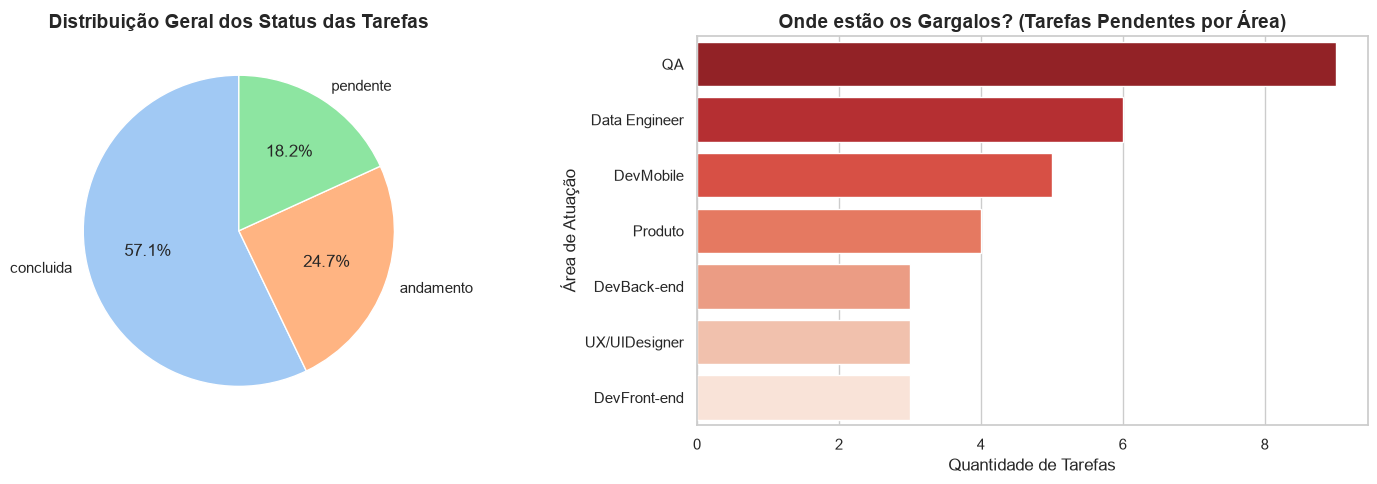

In [ ]:


# Configurando o estilo dos gráficos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

# Gráfico 1: Distribuição de Status
plt.subplot(1, 2, 1)
status_cores = sns.color_palette("pastel")[0:3]
plt.pie(status_qtd, labels=status_qtd.index, autopct='%1.1f%%', startangle=90, colors=status_cores)
plt.title("Distribuição Geral dos Status das Tarefas", fontsize=14, fontweight='bold')

# Gráfico 2: Tarefas Pendentes por Área
plt.subplot(1, 2, 2)
sns.barplot(x=pendentes_por_area.values, y=pendentes_por_area.index, palette="danger_r" if "danger_r" in dir(sns.color_palette) else "Reds_r")
plt.title("Onde estão os Gargalos? (Tarefas Pendentes por Área)", fontsize=14, fontweight='bold')
plt.xlabel("Quantidade de Tarefas")
plt.ylabel("Área de Atuação")

plt.tight_layout()
plt.show()

Analise do dataset a troco de adiantar as metricas, graficos e insights. Quando houver a integração com mongo e etc, ja teremos meio caminho andado


# importacao

# av. geral


In [2]:
tabela.info()
print(f'{tabela.shape}')

tabela.describe()



<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   _id                           77 non-null     object        
 1   task_id                       76 non-null     float64       
 2   titulo                        77 non-null     str           
 3   descricao                     77 non-null     str           
 4   prioridade                    77 non-null     str           
 5   user_id                       77 non-null     object        
 6   mentorado                     77 non-null     str           
 7   area_atuacao                  76 non-null     str           
 8   mentor_responsavel            77 non-null     str           
 9   data_criacao                  76 non-null     datetime64[us]
 10  data_inicio                   63 non-null     datetime64[us]
 11  status_atual                  77 non-null    

,task_id,data_criacao,data_inicio,data_conclusao,createdAt,updatedAt,__v
count,76.000000,76,63,44,1,1,1.0
mean,38.500000,2026-04-18 14:31:34.736842,2026-04-14 17:54:17.142857,2026-04-12 08:10:54.545454,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
min,1.000000,2026-03-01 00:00:00,2026-03-03 00:00:00,2026-03-09 00:00:00,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
25%,19.750000,2026-03-23 18:00:00,2026-03-23 12:00:00,2026-03-27 06:00:00,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
50%,38.500000,2026-04-28 00:00:00,2026-04-16 00:00:00,2026-04-05 12:00:00,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
75%,57.250000,2026-05-12 00:00:00,2026-05-08 12:00:00,2026-04-29 06:00:00,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
max,76.000000,2026-05-27 00:00:00,2026-06-11 00:00:00,2026-06-15 00:00:00,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
std,22.083176,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
#conversao de valores para tipos adequados
tabela['task_id'] = tabela['task_id'].astype('object')
print(f"Coluna 'task_id' convertida para o tipo '{tabela['task_id'].dtype}'")


Coluna 'task_id' convertida para o tipo 'object'


In [4]:
tabela.info()

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   _id                           77 non-null     object        
 1   task_id                       76 non-null     object        
 2   titulo                        77 non-null     str           
 3   descricao                     77 non-null     str           
 4   prioridade                    77 non-null     str           
 5   user_id                       77 non-null     object        
 6   mentorado                     77 non-null     str           
 7   area_atuacao                  76 non-null     str           
 8   mentor_responsavel            77 non-null     str           
 9   data_criacao                  76 non-null     datetime64[us]
 10  data_inicio                   63 non-null     datetime64[us]
 11  status_atual                  77 non-null    

In [5]:
tabela.head()

,_id,task_id,titulo,descricao,prioridade,user_id,mentorado,area_atuacao,mentor_responsavel,data_criacao,data_inicio,status_atual,data_conclusao,feedback_conclusao_mentorado,createdAt,updatedAt,__v
0,6a2b884993a2aac46c8ba14a,1.0,Otimizar Microsserviços - Sprint 8,Atividade focada em otimizar o recurso de micr...,media,6a2b8445cf36b576d237ae6b,Bruno Costa,DevBack-end,Juliana Costa,2026-05-05,2026-05-07,andamento,NaT,NaN,NaT,NaT,NaN
1,6a2b884993a2aac46c8ba14b,2.0,Testar Scripts de Deploy - Sprint 2,Atividade focada em testar o recurso de script...,alta,6a2b8468cf36b576d237ae6c,Felipe Andrade,QA,Juliana Costa,2026-03-25,2026-03-27,concluida,2026-04-02,Os testes cobriram os cenários críticos de aut...,NaT,NaT,NaN
2,6a2b884993a2aac46c8ba14c,3.0,Testar Cache em Redis - Sprint 2,Atividade focada em testar o recurso de cache ...,media,6a2b8468cf36b576d237ae6c,Felipe Andrade,QA,Juliana Costa,2026-03-26,2026-03-27,concluida,2026-04-06,Validação executada com sucesso. O fluxo corre...,NaT,NaT,NaN
3,6a2b884993a2aac46c8ba14d,4.0,Testar Componentes React - Sprint 8,Atividade focada em testar o recurso de compon...,media,6a2b8496cf36b576d237ae6d,Diego Martins,QA,Juliana Costa,2026-04-20,2026-04-21,concluida,2026-04-27,Conseguimos manter uma boa cobertura de testes...,NaT,NaT,NaN
4,6a2b884993a2aac46c8ba14e,5.0,Ajustar Exportação de Relatórios - Sprint 3,Atividade focada em ajustar o recurso de expor...,media,6a2b84b4cf36b576d237ae6e,Camila Lopes,Produto,Juliana Costa,2026-03-02,2026-03-05,concluida,2026-03-19,Os ajustes visuais foram concluídos no prazo. ...,NaT,NaT,NaN


In [6]:
tabela.drop(columns=['descricao', 'mentor_responsavel', 'createdAt','updatedAt','__v', '_id'], inplace=True, errors='ignore')

In [7]:
##como temos valores nulos de data de inicio e data de  conclusao q estao nulos, estamos falando de atividades que não foram concluidas/iniadas
tabela.isnull().sum()

task_id                          1
titulo                           0
prioridade                       0
user_id                          0
mentorado                        0
area_atuacao                     1
data_criacao                     1
data_inicio                     14
status_atual                     0
data_conclusao                  33
feedback_conclusao_mentorado    33
dtype: int64

In [8]:
tabela.duplicated().sum()

np.int64(0)

In [9]:
tabela.head()

,task_id,titulo,prioridade,user_id,mentorado,area_atuacao,data_criacao,data_inicio,status_atual,data_conclusao,feedback_conclusao_mentorado
0,1.0,Otimizar Microsserviços - Sprint 8,media,6a2b8445cf36b576d237ae6b,Bruno Costa,DevBack-end,2026-05-05,2026-05-07,andamento,NaT,NaN
1,2.0,Testar Scripts de Deploy - Sprint 2,alta,6a2b8468cf36b576d237ae6c,Felipe Andrade,QA,2026-03-25,2026-03-27,concluida,2026-04-02,Os testes cobriram os cenários críticos de aut...
2,3.0,Testar Cache em Redis - Sprint 2,media,6a2b8468cf36b576d237ae6c,Felipe Andrade,QA,2026-03-26,2026-03-27,concluida,2026-04-06,Validação executada com sucesso. O fluxo corre...
3,4.0,Testar Componentes React - Sprint 8,media,6a2b8496cf36b576d237ae6d,Diego Martins,QA,2026-04-20,2026-04-21,concluida,2026-04-27,Conseguimos manter uma boa cobertura de testes...
4,5.0,Ajustar Exportação de Relatórios - Sprint 3,media,6a2b84b4cf36b576d237ae6e,Camila Lopes,Produto,2026-03-02,2026-03-05,concluida,2026-03-19,Os ajustes visuais foram concluídos no prazo. ...


# analisegeral


In [10]:
databcorte = pd.to_datetime('2026-05-31') #é a fotografia da data, é oq nos ajuda a criar o limite pra uma data que não existe, exemplo data_inicio ou data_conclusao. Ela pode ser modificada, podemos dar outro parametro de data.

tabela['duracao_em_dias'] = np.nan #criar uma coluna vazia para receber os calculos

taskconcluida = tabela['status_atual'] == 'concluida'
tabela.loc[taskconcluida, 'duracao_em_dias'] = (tabela.loc[taskconcluida, 'data_conclusao'] - tabela.loc[taskconcluida, 'data_inicio']).dt.days  # CONCLUIDAS = DATAINICIO - DATACONCLUSAO.

# 'andamento' status
task_andamento = tabela['status_atual'] == 'andamento'
tabela.loc[task_andamento, 'duracao_em_dias'] = (databcorte - tabela.loc[task_andamento, 'data_inicio']).dt.days #DATA CORTE AGR É UMA DATA Q O SISTEMA TA DANDO COMO LIMITE PARA AS ATVD Q ESTAO EM ANDAMENTO. como se ele dissesse: Olhe, datacorte-datainicio = a qntdade de dias q ja se passaram e vc ainda ta em andamento com a atvd

# 'pendente' status
task_pendente = tabela['status_atual'] == 'pendente'
tabela.loc[task_pendente, 'duracao_em_dias'] = (databcorte - tabela.loc[task_pendente, 'data_criacao']).dt.days # ele vai pegar a datacorte - datacriacao e sinalizar: olhe, ate agora(data_corte), vc ta com essa atividade ha X dias no blocklog


#duraçao em dias para saber quantos dias aquela tarefa foi concluida ou esta em processo/pendente
concluidas = tabela[tabela['status_atual'] == 'concluida']
andamento = tabela[tabela['status_atual'] == 'andamento']
pendentes = tabela[tabela['status_atual'] == 'pendente']

# Calcular as médias isoladas (arredondadas a 1 casa decimal). O papel da média vai nos dizer: se a quantidade de dias que a atvd ta em execução/pendente é maior que a média, ai isso ja dá um alerta pra o mentor conversar procurar o mentorado e entender oq se passa
media_dia_conclusao = concluidas['duracao_em_dias'].mean().round(1)
media_dia_andamento = andamento['duracao_em_dias'].mean().round(1)
media_dia_pendente = pendentes['duracao_em_dias'].mean().round(1)


print(f'a media de dias para concluir é: {media_dia_conclusao}')
print(f'a media de dias que a atv ESTÁ EM ANDAMENTO é: {media_dia_andamento}' )
print(f'a media de dias de atv pendente é: {media_dia_pendente}')
print(concluidas)
print('===========')
print(andamento)
print('===========')
print(pendentes)

a media de dias para concluir é: 10.6
a media de dias que a atv ESTÁ EM ANDAMENTO é: 16.2
a media de dias de atv pendente é: 11.8
   task_id                                          titulo prioridade  \
1      2.0             Testar Scripts de Deploy - Sprint 2       alta   
2      3.0                Testar Cache em Redis - Sprint 2      media   
3      4.0             Testar Componentes React - Sprint 8      media   
4      5.0     Ajustar Exportação de Relatórios - Sprint 3      media   
7      8.0              Criar Scripts de Deploy - Sprint 2       alta   
9     10.0                      Criar Dashboard - Sprint 1      media   
10    11.0             Atualizar Pipeline CI/CD - Sprint 1      media   
11    12.0             Refatorar Microsserviços - Sprint 5      media   
12    13.0               Refatorar API de Login - Sprint 5       alta   
13    14.0             Documentar Tabelas no BD - Sprint 4      baixa   
14    15.0                 Criar Pipeline CI/CD - Sprint 6       al

In [11]:
tabela.info()

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   task_id                       76 non-null     object        
 1   titulo                        77 non-null     str           
 2   prioridade                    77 non-null     str           
 3   user_id                       77 non-null     object        
 4   mentorado                     77 non-null     str           
 5   area_atuacao                  76 non-null     str           
 6   data_criacao                  76 non-null     datetime64[us]
 7   data_inicio                   63 non-null     datetime64[us]
 8   status_atual                  77 non-null     str           
 9   data_conclusao                44 non-null     datetime64[us]
 10  feedback_conclusao_mentorado  44 non-null     str           
 11  duracao_em_dias               77 non-null    

In [123]:
tabela['status_atual'].value_counts()
print(f'{tabela["status_atual"].value_counts()}')

#agr sabemos como estao as atividades e os status gerais

status_atual
concluida    44
andamento    19
pendente     14
Name: count, dtype: int64


In [124]:
#
tabela['status_atual'].value_counts(normalize=True) * 100

status_atual
concluida    57.142857
andamento    24.675325
pendente     18.181818
Name: proportion, dtype: float64

In [125]:
#distribuição de status_atual por mentorado
tabela.groupby('mentorado')['status_atual'].value_counts(normalize=True) * 100

#podemos tirar daqui q o caount nos mostra quantas vezes os mentorados tem atividade

mentorado       status_atual
Ana Ribeiro     concluida        62.500000
                pendente         18.750000
                andamento        18.750000
Bruno Costa     concluida        70.000000
                pendente         20.000000
                andamento        10.000000
Camila Lopes    concluida        42.857143
                pendente         42.857143
                andamento        14.285714
Diego Martins   pendente         44.444444
                concluida        33.333333
                andamento        22.222222
Eduarda Souza   concluida        70.000000
                andamento        30.000000
Felipe Andrade  concluida        70.000000
                andamento        20.000000
                pendente         10.000000
Gabriela Pinto  concluida        50.000000
                andamento        40.000000
                pendente         10.000000
Henrique Alves  andamento        75.000000
                concluida        25.000000
Milenna Xavier  concluida

In [126]:
tabela.info()

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   _id                           77 non-null     object        
 1   task_id                       76 non-null     object        
 2   titulo                        77 non-null     str           
 3   prioridade                    77 non-null     str           
 4   user_id                       77 non-null     object        
 5   mentorado                     77 non-null     str           
 6   area_atuacao                  76 non-null     str           
 7   data_criacao                  76 non-null     datetime64[us]
 8   data_inicio                   63 non-null     datetime64[us]
 9   status_atual                  77 non-null     str           
 10  data_conclusao                44 non-null     datetime64[us]
 11  feedback_conclusao_mentorado  44 non-null    

In [127]:
media_por_prioridade = tabela.groupby('prioridade')['duracao_em_dias'].mean().round(1)
print(media_por_prioridade)
mediana_por_prioridade = tabela.groupby('prioridade')['duracao_em_dias'].median().round(1)
print(mediana_por_prioridade)

prioridade
alta     11.3
baixa    11.6
media    13.5
Name: duracao_em_dias, dtype: float64
prioridade
alta     10.0
baixa    12.5
media    14.0
Name: duracao_em_dias, dtype: float64


#EDA -  MENTORADA


In [128]:
mentorada = tabela[tabela['mentorado'] == 'Ana Ribeiro'].copy()
mentorada.head(16)

,_id,task_id,titulo,prioridade,user_id,mentorado,area_atuacao,data_criacao,data_inicio,status_atual,data_conclusao,feedback_conclusao_mentorado,createdAt,updatedAt,__v,duracao_em_dias
7,6a2b884993a2aac46c8ba151,8.0,Criar Scripts de Deploy - Sprint 2,alta,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,2026-04-20,2026-04-21,concluida,2026-04-30,Atividade finalizada com sucesso. A automação ...,NaT,NaT,NaN,9.0
10,6a2b884993a2aac46c8ba154,11.0,Atualizar Pipeline CI/CD - Sprint 1,media,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,2026-03-04,2026-03-05,concluida,2026-03-12,Otimizamos o tempo total do fluxo de integraçã...,NaT,NaT,NaN,7.0
13,6a2b884993a2aac46c8ba157,14.0,Documentar Tabelas no BD - Sprint 4,baixa,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,2026-04-15,2026-04-16,concluida,2026-05-01,Dicionário de dados atualizado com sucesso no ...,NaT,NaT,NaN,15.0
14,6a2b884993a2aac46c8ba158,15.0,Criar Pipeline CI/CD - Sprint 6,alta,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,2026-04-21,2026-04-23,concluida,2026-05-10,Pipeline criado do zero para os novos serviços...,NaT,NaT,NaN,17.0
17,6a2b884993a2aac46c8ba15b,18.0,Implementar Scripts de Deploy - Sprint 1,alta,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,2026-05-12,2026-05-17,andamento,NaT,NaN,NaT,NaT,NaN,14.0
21,6a2b884993a2aac46c8ba15f,22.0,Documentar Tabelas no BD - Sprint 6,baixa,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,2026-03-20,2026-03-22,concluida,2026-04-01,Documentação finalizada englobando os esquemas...,NaT,NaT,NaN,10.0
30,6a2b884993a2aac46c8ba168,31.0,Atualizar Scripts de Deploy - Sprint 6,alta,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,2026-05-08,2026-05-11,concluida,2026-05-31,Adicionamos notificações via Slack e tratament...,NaT,NaT,NaN,20.0
31,6a2b884993a2aac46c8ba169,32.0,Ajustar Pipeline CI/CD - Sprint 9,alta,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,2026-03-05,2026-03-08,concluida,2026-03-13,Ajustamos os gatilhos para evitar deploys acid...,NaT,NaT,NaN,5.0
34,6a2b884993a2aac46c8ba16c,35.0,Implementar Tabelas no BD - Sprint 5,alta,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,2026-05-14,NaT,pendente,NaT,NaN,NaT,NaT,NaN,17.0
36,6a2b884993a2aac46c8ba16e,37.0,Otimizar Pipeline CI/CD - Sprint 2,media,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,2026-05-10,NaT,pendente,NaT,NaN,NaT,NaT,NaN,21.0


In [129]:
media_prioridade_Ana = mentorada.groupby('prioridade')['duracao_em_dias'].mean().round(1)
print(media_prioridade_Ana)

prioridade
alta     11.2
baixa    12.5
media    15.7
Name: duracao_em_dias, dtype: float64


In [130]:
media_por_status_ana = mentorada.groupby('status_atual')['duracao_em_dias'].mean().round(1)
print(media_por_status_ana)

status_atual
andamento     7.0
concluida    13.2
pendente     14.0
Name: duracao_em_dias, dtype: float64


In [131]:
mentorada.describe()

,data_criacao,data_inicio,data_conclusao,createdAt,updatedAt,__v,duracao_em_dias
count,16,13,10,0,0,0.0,16.000000
mean,2026-04-19 09:00:00,2026-04-15 07:23:04.615384,2026-04-16 21:36:00,NaT,NaT,NaN,12.187500
min,2026-03-03 00:00:00,2026-03-04 00:00:00,2026-03-12 00:00:00,NaT,NaT,NaN,2.000000
25%,2026-03-21 12:00:00,2026-03-22 00:00:00,2026-03-25 06:00:00,NaT,NaT,NaN,6.500000
50%,2026-04-22 12:00:00,2026-04-21 00:00:00,2026-04-17 12:00:00,NaT,NaT,NaN,12.500000
75%,2026-05-12 12:00:00,2026-05-11 00:00:00,2026-05-07 18:00:00,NaT,NaT,NaN,17.500000
max,2026-05-27 00:00:00,2026-05-29 00:00:00,2026-05-31 00:00:00,NaT,NaT,NaN,21.000000
std,NaN,NaN,NaN,NaN,NaN,NaN,6.358393


In [132]:
duracao_em_dias_series = mentorada['duracao_em_dias']

duracao_em_dias_series.quantile([0.25, 0.5, 0.75])
IQR = duracao_em_dias_series.quantile(0.75) - duracao_em_dias_series.quantile(0.25)
print(IQR)
Q1 = duracao_em_dias_series.quantile(0.25)
Q3 = duracao_em_dias_series.quantile(0.75)
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
print(f'Limite Inferior: {limite_inferior}')
print(f'Limite Superior: {limite_superior}')

11.0
Limite Inferior: -10.0
Limite Superior: 34.0


In [133]:
historico = tabela[tabela['status_atual'] == 'concluida']# vai se basear nas entregas do geral de mentorados
media_geral_por_prioridade = historico.groupby('prioridade')['duracao_em_dias'].mean().round(0) #usamos os dados do dataset geral
print(media_geral_por_prioridade)


tarefas_ativas = mentorada[mentorada['status_atual'].isin(['andamento', 'pendente'])].copy()
tarefas_ativas['tempo_limite'] = tarefas_ativas['prioridade'].map(media_geral_por_prioridade) # O .map() olha a prioridade da tarefa e "cola" o tempo limite exato na coluna ao lado.
print(tarefas_ativas)

prioridade
alta     10.0
baixa    10.0
media    11.0
Name: duracao_em_dias, dtype: float64
                         _id task_id  \
17  6a2b884993a2aac46c8ba15b    18.0   
34  6a2b884993a2aac46c8ba16c    35.0   
36  6a2b884993a2aac46c8ba16e    37.0   
49  6a2b884993a2aac46c8ba17b    50.0   
56  6a2b884993a2aac46c8ba182    57.0   
66  6a2b884993a2aac46c8ba18c    67.0   

                                      titulo prioridade  \
17  Implementar Scripts de Deploy - Sprint 1       alta   
34      Implementar Tabelas no BD - Sprint 5       alta   
36        Otimizar Pipeline CI/CD - Sprint 2      media   
49           Criar Pipeline CI/CD - Sprint 7       alta   
56     Otimizar Scripts de Deploy - Sprint 8       alta   
66    Atualizar Scripts de Deploy - Sprint 9       alta   

                     user_id    mentorado   area_atuacao data_criacao  \
17  6a2b84ddcf36b576d237ae70  Ana Ribeiro  Data Engineer   2026-05-12   
34  6a2b84ddcf36b576d237ae70  Ana Ribeiro  Data Engineer   2026-05-1

In [134]:
historico = tabela[tabela['status_atual'] == 'concluida']# vai se basear nas entregas do geral de mentorados
media_geral_por_prioridade = historico.groupby('prioridade')['duracao_em_dias'].mean().round(0) #usamos os dados do dataset geral
print(media_geral_por_prioridade)


tarefas_ativas = tabela[tabela['status_atual'].isin(['andamento', 'pendente'])].copy()
tarefas_ativas['tempo_limite'] = tarefas_ativas['prioridade'].map(media_geral_por_prioridade) # O .map() olha a prioridade da tarefa e "cola" o tempo limite exato na coluna ao lado.
print(tarefas_ativas)

prioridade
alta     10.0
baixa    10.0
media    11.0
Name: duracao_em_dias, dtype: float64
                         _id task_id  \
0   6a2b884993a2aac46c8ba14a     1.0   
5   6a2b884993a2aac46c8ba14f     6.0   
6   6a2b884993a2aac46c8ba150     7.0   
8   6a2b884993a2aac46c8ba152     9.0   
15  6a2b884993a2aac46c8ba159    16.0   
17  6a2b884993a2aac46c8ba15b    18.0   
18  6a2b884993a2aac46c8ba15c    19.0   
23  6a2b884993a2aac46c8ba161    24.0   
24  6a2b884993a2aac46c8ba162    25.0   
25  6a2b884993a2aac46c8ba163    26.0   
26  6a2b884993a2aac46c8ba164    27.0   
27  6a2b884993a2aac46c8ba165    28.0   
28  6a2b884993a2aac46c8ba166    29.0   
29  6a2b884993a2aac46c8ba167    30.0   
34  6a2b884993a2aac46c8ba16c    35.0   
36  6a2b884993a2aac46c8ba16e    37.0   
37  6a2b884993a2aac46c8ba16f    38.0   
38  6a2b884993a2aac46c8ba170    39.0   
40  6a2b884993a2aac46c8ba172    41.0   
42  6a2b884993a2aac46c8ba174    43.0   
45  6a2b884993a2aac46c8ba177    46.0   
46  6a2b884993a2aac46c8ba178 

In [135]:
mentorada.info()

<class 'pandas.DataFrame'>
Index: 16 entries, 7 to 71
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   _id                           16 non-null     object        
 1   task_id                       16 non-null     object        
 2   titulo                        16 non-null     str           
 3   prioridade                    16 non-null     str           
 4   user_id                       16 non-null     object        
 5   mentorado                     16 non-null     str           
 6   area_atuacao                  16 non-null     str           
 7   data_criacao                  16 non-null     datetime64[us]
 8   data_inicio                   13 non-null     datetime64[us]
 9   status_atual                  16 non-null     str           
 10  data_conclusao                10 non-null     datetime64[us]
 11  feedback_conclusao_mentorado  10 non-null     str 

In [136]:
mentorada.isnull().sum()

_id                              0
task_id                          0
titulo                           0
prioridade                       0
user_id                          0
mentorado                        0
area_atuacao                     0
data_criacao                     0
data_inicio                      3
status_atual                     0
data_conclusao                   6
feedback_conclusao_mentorado     6
createdAt                       16
updatedAt                       16
__v                             16
duracao_em_dias                  0
dtype: int64

In [137]:
mentorada.duplicated().sum()

np.int64(0)

#GRAFICOS

##card - valores totais, médias gerais, ou algo muito expecidfico

In [138]:
datacorte = pd.to_datetime('2026-05-31') #valor para parametro de atvs n iniciadas ou em andamento, ja sabemos as atvds q foram finalizadas

O total de atividade de Ana é: 16


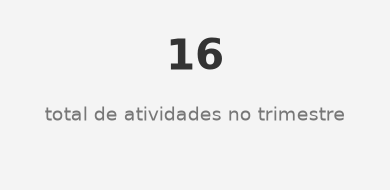

In [139]:
#CARD total de atividade escaladas(sugestao)
import matplotlib.pyplot as plt
mentorada['status_atual'].count()
print(f'O total de atividade de Ana é: {mentorada["status_atual"].count()}')


fig, ax = plt.subplots(figsize=(4, 2))
ax.patch.set_facecolor('#f4f4f4')
fig.patch.set_facecolor('#f4f4f4')

# Remover bordas
for spine in ax.spines.values():
    spine.set_visible(False)

# Remover eixos
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

# Textos do card (métrica e label)
ax.text(0.5, 0.65, '16', fontsize=30, fontweight='bold', ha='center', color='#333333')
ax.text(0.5, 0.35, 'total de atividades no trimestre', fontsize=14, ha='center', color='#777777')

plt.tight_layout()
plt.show()

Total de atividade concluidas de Ana é: 10


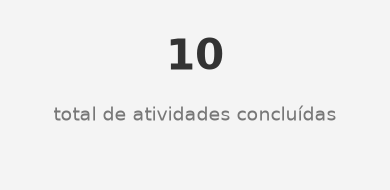

In [140]:
#card total de atividades concluidas no trimestre
total_concluidas = mentorada[mentorada['status_atual'] == 'concluida'].shape[0]
print(f'Total de atividade concluidas de Ana é: {total_concluidas}')

fig, ax = plt.subplots(figsize=(4, 2))
ax.patch.set_facecolor('#f4f4f4')
fig.patch.set_facecolor('#f4f4f4')

# Remover bordas
for spine in ax.spines.values():
    spine.set_visible(False)

# Remover eixos
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

# Textos do card (métrica e label)
ax.text(0.5, 0.65, str(total_concluidas), fontsize=30, fontweight='bold', ha='center', color='#333333')
ax.text(0.5, 0.35, 'total de atividades concluídas', fontsize=14, ha='center', color='#777777')

plt.tight_layout()
plt.show()

tempo médio(em dias) da conclusão é:13.2
tempo médio(em dias) do andamento é:7.0
tempo médio(em dias) da pendencia é:14.0


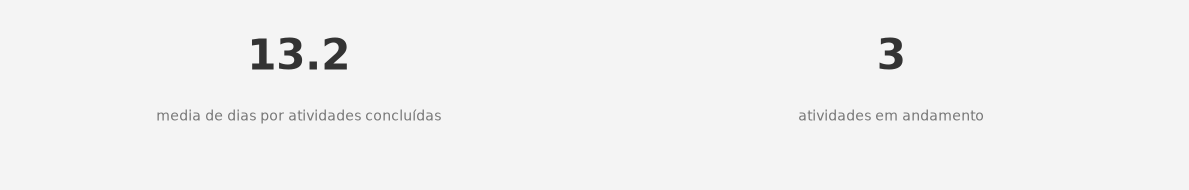

In [141]:
#CARD TEMPO MEDIO POR ENTREGA
mediaconclusao = mentorada[mentorada['status_atual'] == 'concluida']['duracao_em_dias'].mean().round(1)
print(f'tempo médio(em dias) da conclusão é:{mediaconclusao}')
#card tempo medio por atividade em processo
mediandamento = mentorada[mentorada['status_atual'] == 'andamento']['duracao_em_dias'].mean().round(1)
print(f'tempo médio(em dias) do andamento é:{mediandamento}')
#card tempo medio que uma atividade fica pendente
mediapendente = mentorada[mentorada['status_atual'] == 'pendente']['duracao_em_dias'].mean().round(1)
print(f'tempo médio(em dias) da pendencia é:{mediapendente}')

TotalAtvAndamento = len(mentorada[mentorada['status_atual'] == 'andamento'])
fig, axes = plt.subplots(1, 2, figsize=(12, 2)) # 1 row, 2 columns

# Card 1: Concluídas
ax = axes[0]
ax.patch.set_facecolor('#f4f4f4')
fig.patch.set_facecolor('#f4f4f4')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.text(0.5, 0.65, str(mediaconclusao), fontsize=30, fontweight='bold', ha='center', color='#333333', transform=ax.transAxes)
ax.text(0.5, 0.35, 'media de dias por atividades concluídas', fontsize=10, ha='center', color='#777777', transform=ax.transAxes)

# Card 2: Em Andamento
ax = axes[1]
ax.patch.set_facecolor('#f4f4f4')
fig.patch.set_facecolor('#f4f4f4')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.text(0.5, 0.65, str(TotalAtvAndamento), fontsize=30, fontweight='bold', ha='center', color='#333333', transform=ax.transAxes)
ax.text(0.5, 0.35, 'atividades em andamento', fontsize=10, ha='center', color='#777777', transform=ax.transAxes)


plt.tight_layout()
plt.show()

## PIZZA GRAFICO



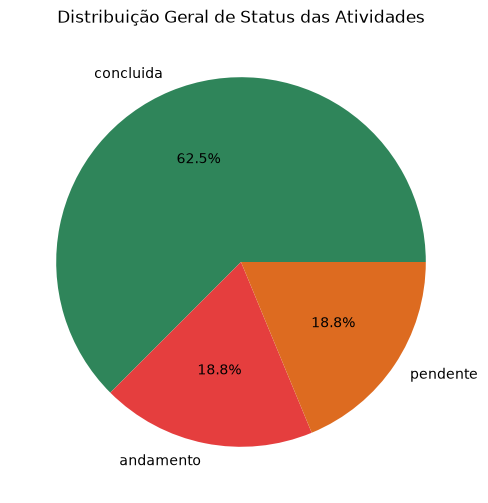

status_atual
concluida    10
andamento     3
pendente      3
Name: count, dtype: int64


In [142]:
#porcentagem de atividadesZ
status_andamento = mentorada['status_atual'].value_counts(normalize=True) * 100
#mentorada['status_atual'].value_counts(normalize=True) * 100 (para calcular ser ver o grafico)

# --- GRÁFICO 1: PIZZA (%STATUS DE TAREFAS DA MENTORA) ---

status_andamento = mentorada['status_atual'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(status_andamento, labels=status_andamento.index, autopct='%1.1f%%', colors=['#2f855a', '#e53e3e', '#dd6b20'])
plt.title('Distribuição Geral de Status das Atividades')
plt.savefig('grafico_status.png', transparent=True)

plt.show()
print(status_andamento)

GRAFICO DINAMICO

In [143]:
# o grafico grande que é aO GRAFICO DE ANA Q MOSTRA AS ENTREGAS AO LONGO DAS SPRINGS.

#base ado nos dados gerais de todos os mentorados
concluidas_equipe = tabela[tabela['status_atual'] == 'concluida']
media_equipe = concluidas_equipe['duracao_em_dias'].mean()
teto_do_grafico = concluidas_equipe['duracao_em_dias'].max() + 2

# 2. pra cada atividade
mapa_de_cores = {
    'alta': '#E74C3C',    # Vermelho Alerta
    'Alta': '#E74C3C',
    'média': '#F39C12',   # Laranja/Amarelo Atenção
    'media': '#F39C12',
    'Média': '#F39C12',
    'baixa': '#2ECC71',   # Verde Tranquilo
    'Baixa': '#2ECC71'
}

# 3. definir grafico
def criar_grafico_evolucao(dataset_alvo, titulo_do_grafico):

    df_plot = dataset_alvo[dataset_alvo['status_atual'] == 'concluida'].copy()

#separar por sring
    df_plot['sprint_num'] = df_plot['titulo'].str.extract(r'Sprint (\d+)').astype(int)
    df_plot['nome_sprint'] = df_plot['titulo'].str.extract(r'(Sprint \d+)')
    df_plot = df_plot.sort_values('sprint_num')

    fig = px.scatter(
        df_plot,
        x='nome_sprint',
        y='duracao_em_dias',
        color='prioridade',
        color_discrete_map=mapa_de_cores,
        hover_data=['titulo', 'mentorado'],
        title=titulo_do_grafico,
        labels={'duracao_em_dias': 'Dias Gastos', 'nome_sprint': 'Sprint', 'prioridade': 'Dificuldade'}
    )

    fig.add_hline(
        y=media_equipe,
        line_dash="dash",
        line_color="gray",
        annotation_text=f"Média Geral ({media_equipe:.1f} dias)",
        annotation_position="bottom right"
    )

    # bolas do grafico
    fig.update_traces(marker=dict(size=14, opacity=0.8, line=dict(width=1, color='DarkSlateGrey')))
    fig.update_yaxes(range=[0, teto_do_grafico])

    return fig

# 3. GERANDO OS DOIS GRÁFICOS COM 1 LINHA DE CÓDIGO CADA

grafico_ana = criar_grafico_evolucao(mentorada, "Visão da Ana: Minha Evolução Individual")

# Exibindo as duas obras de arte

grafico_ana.show()

#oq esta acontecendo? : ele pega os dias gastos(duraçao_em_dias das atividades CONCLUIDAS) e coloca as sprint, ai podemos ver, de forma dinamica, as tarefas q foram concluidas, e as informações contidas

##Tabela

In [144]:

#usar o historico de entregas de todos os mentorados para ter um parametro de atividade dos mentorados atravez das
historico_geral = tabela[tabela['status_atual'] == 'concluida']
media_por_prioridade = historico_geral.groupby('prioridade')['duracao_em_dias'].mean().round(1)

tabela_ativas_ana = mentorada[mentorada['status_atual'].isin(['andamento', 'pendente'])].copy()

# Injetamos a meta na tabela da Ana cruzando a prioridade
mentorada['meta_dias'] = mentorada['prioridade'].map(media_por_prioridade)

def sinalizar_status_real(linha): #verificação linha por linha do pandas para chegar nos resultados
    dias = linha['duracao_em_dias'] #mostra há quantos dias aquela atividade está rolando (desde que foi criada ou iniciada até a nossa data de corte).
    meta = linha['meta_dias_ana'] # é a media_por_prioridade que esta convertida em tabela

    if linha['status_atual'] == 'pendente':
        return '🔴 Crítico (Fila)' if dias > 10 else '⚪ Pendente Normal'

    elif linha['status_atual'] == 'andamento':
        if dias > (meta * 2):
            return '🔴 Crítico'
        elif dias > meta:
            return '🟡 Atrasado'
        else:
            # Adicionado para tarefas em 'andamento' mas 'Dentro do Prazo'
            return '🟢 Dentro do Prazo'
    else:
        # Adicionado para tarefas 'concluida' que não tinham retorno
        return '✔️ Entregue'

mentorada['Diagnostico'] = mentorada.apply(sinalizar_status_real, axis=1)
mentorada['dias_de_atraso'] = mentorada['duracao_em_dias'] - mentorada['meta_dias_ana']

atvd_ativa_ = mentorada[mentorada['status_atual'].isin(['andamento', 'pendente'])].copy()
tabela_completa_ana = atvd_ativa_[[
    'titulo', 'mentorado', 'prioridade', 'status_atual',
    'duracao_em_dias', 'meta_dias_ana', 'dias_de_atraso', 'Diagnostico'
]].sort_values(by='dias_de_atraso', ascending=False)




condicao_problema_ana = tabela_completa_ana['Diagnostico'].str.contains('🔴|🟡')
tabela_problemas_ana = tabela_completa_ana[condicao_problema_ana].drop(columns=['dias_de_atraso'])


print("=== TABELA DE visualização de atividades não entregues) ===")
display(tabela_problemas_ana)


KeyError: 'meta_dias_ana'

In [145]:
# 2. TABELA DE FLUXO NORMAL (Apenas 🟢 Prazo e ⚪ Fila Normal)
condicao_saudavel_ana = tabela_completa_ana['Diagnostico'].str.contains('🟢|⚪')
tabela_saudaveis_ana = tabela_completa_ana[condicao_saudavel_ana].drop(columns=['dias_de_atraso'])


display(tabela_saudaveis_ana)


,titulo,mentorado,prioridade,status_atual,duracao_em_dias,meta_dias_ana,Diagnostico
66,Atualizar Scripts de Deploy - Sprint 9,Ana Ribeiro,alta,andamento,5.0,9.9,🟢 Dentro do Prazo
56,Otimizar Scripts de Deploy - Sprint 8,Ana Ribeiro,alta,pendente,4.0,9.9,⚪ Pendente Normal
49,Criar Pipeline CI/CD - Sprint 7,Ana Ribeiro,alta,andamento,2.0,9.9,🟢 Dentro do Prazo


TABELA PARA VISUALIZAR OS SALDOS DE TODOS OS MENTORADOS E SUAS ATIVIDADES Q ESTAO FORA DA

In [146]:

#tabela geral
historico_geral = tabela[tabela['status_atual'] == 'concluida']
media_por_prioridade = historico_geral.groupby('prioridade')['duracao_em_dias'].mean().round(1)

tabela_ativas_ana = tabela[tabela['status_atual'].isin(['andamento', 'pendente'])].copy()

# Injetamos a meta na tabela tabela cruzando a prioridade
tabela['meta_dias'] = tabela['prioridade'].map(media_por_prioridade)

def sinalizar_status_real(linha):
    dias = linha['duracao_em_dias']
    meta = linha['meta_dias']

    if linha['status_atual'] == 'pendente':
        return '🔴 Crítico (Fila)' if dias > 10 else '⚪ Pendente Normal'

    elif linha['status_atual'] == 'andamento':
        if dias > (meta * 2):
            return '🔴 Crítico'
        elif dias > meta:
            return '🟡 Atrasado'
        else:
            # Adicionado para tarefas em 'andamento' mas 'Dentro do Prazo'
            return '🟢 Dentro do Prazo'
    else:
        # Adicionado para tarefas 'concluida' que não tinham retorno
        return '✔️ Entregue'

tabela['Diagnostico'] = tabela.apply(sinalizar_status_real, axis=1)
tabela['dias_de_atraso'] = tabela['duracao_em_dias'] - tabela['meta_dias']

# Pegamos apenas quem NÃO está concluído
tabela_ativas = tabela[tabela['status_atual'].isin(['andamento', 'pendente'])].copy()


tabela_completa = tabela_ativas[[
    'titulo', 'mentorado', 'prioridade', 'status_atual',
    'duracao_em_dias', 'meta_dias', 'dias_de_atraso', 'Diagnostico'
]].sort_values(by='dias_de_atraso', ascending=False)


#fazer o filtro para não mostrar nada que esteja ok, entregue ou no prazo
condicao_problema = tabela_completa['Diagnostico'].str.contains('🔴|🟡')
tabela_problemas = tabela_completa[condicao_problema].drop(columns=['dias_de_atraso'])


print("=== TABELA DE verificação de tividades não entregues")
display(tabela_problemas)


=== TABELA DE verificação de tividades não entregues


,titulo,mentorado,prioridade,status_atual,duracao_em_dias,meta_dias,Diagnostico
46,Testar Fluxo de Autenticação - Sprint 3,Felipe Andrade,alta,andamento,24.0,9.9,🔴 Crítico
5,Documentar Acessibilidade (WCAG) - Sprint 7,Henrique Alves,baixa,andamento,24.0,10.2,🔴 Crítico
45,Testar Scripts de Deploy - Sprint 2,Diego Martins,alta,andamento,23.0,9.9,🔴 Crítico
0,Otimizar Microsserviços - Sprint 8,Bruno Costa,media,andamento,24.0,11.4,🔴 Crítico
8,Atualizar Acessibilidade (WCAG) - Sprint 1,Henrique Alves,media,andamento,24.0,11.4,🔴 Crítico
57,Implementar Fluxo de Autenticação - Sprint 10,Gabriela Pinto,alta,andamento,22.0,9.9,🔴 Crítico
38,Testar Componentes React - Sprint 9,Diego Martins,media,andamento,23.0,11.4,🔴 Crítico
23,Testar Scripts de Deploy - Sprint 2,Felipe Andrade,alta,andamento,20.0,9.9,🔴 Crítico
47,Analisar Pipeline CI/CD - Sprint 2,Felipe Andrade,baixa,pendente,20.0,10.2,🔴 Crítico (Fila)
36,Otimizar Pipeline CI/CD - Sprint 2,Ana Ribeiro,media,pendente,21.0,11.4,🔴 Crítico (Fila)


In [ ]:
# 2. TABELA DE FLUXO NORMAL (Apenas 🟢 Prazo e ⚪ Fila Normal)
condicao_saudavel = tabela_completa['Diagnostico'].str.contains('🟢|⚪')
tabela_saudaveis = tabela_completa[condicao_saudavel].drop(columns=['dias_de_atraso'])

print("\n=== ✅ FLUXO NORMAL (TUDO SOB CONTROLE) ===")
display(tabela_saudaveis)


=== ✅ FLUXO NORMAL (TUDO SOB CONTROLE) ===


,titulo,mentorado,prioridade,status_atual,duracao_em_dias,meta_dias,Diagnostico
68,Criar Fluxo de Autenticação - Sprint 5,Gabriela Pinto,alta,andamento,10.0,10.3,🟢 Dentro do Prazo
18,Criar Componentes React - Sprint 10,Eduarda Souza,alta,andamento,10.0,10.3,🟢 Dentro do Prazo
63,Atualizar Exportação de Relatórios - Sprint 1,Camila Lopes,media,andamento,9.0,11.4,🟢 Dentro do Prazo
53,Implementar Fluxo de Autenticação - Sprint 1,Gabriela Pinto,alta,andamento,6.0,10.3,🟢 Dentro do Prazo
15,Documentar Exportação de Relatórios - Sprint 9,Camila Lopes,baixa,pendente,5.0,10.2,⚪ Pendente Normal
55,Analisar Microsserviços - Sprint 6,Diego Martins,baixa,pendente,5.0,10.2,⚪ Pendente Normal
66,Atualizar Scripts de Deploy - Sprint 9,Ana Ribeiro,alta,andamento,5.0,10.3,🟢 Dentro do Prazo
26,Criar API de Login - Sprint 2,Bruno Costa,alta,pendente,5.0,10.3,⚪ Pendente Normal
27,Implementar Filtros de Busca - Sprint 3,Gabriela Pinto,alta,pendente,4.0,10.3,⚪ Pendente Normal
56,Otimizar Scripts de Deploy - Sprint 8,Ana Ribeiro,alta,pendente,4.0,10.3,⚪ Pendente Normal
